# Demand Forecasting with Censored Likelihood with `numpyro_forecast`

This notebook ports the blog post [**Demand Forecasting with Censored
Likelihood**](https://juanitorduz.github.io/demand/) to the
[`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast)
package. The subject is a fact of retail life: recorded sales understate
demand in two distinct ways. When the product is out of stock, a day of
genuine demand is recorded as zero sales. And when demand exceeds what
the shelf (or the supply) can carry, the register stops counting at the
capacity cap, so the recorded number is a *lower bound* on what
customers actually wanted. A model trained naively on such a series
learns to forecast *sales*, but replenishment and capacity planning need
a forecast of *demand*: order against sales and you bake yesterday’s
stockouts into tomorrow’s assortment, systematically under-serving your
best days.

We simulate a demand series from an AR(2) process with weekly
seasonality, corrupt it into observed sales through random stockouts and
a hard capacity cap, and then fit an AR(2) model with Fourier
seasonality **whose likelihood knows about the censoring**: below the
cap an observation contributes the usual $\text{Normal}$ density, and at
the cap it contributes the *survival mass*
$P(\text{demand} \geq \text{cap})$, the probability that latent demand
was at least as large as the recorded bound. Days with the product off
the shelf are masked out of the likelihood entirely. Because the data
are simulated, the true demand is known and the claim “the censored
likelihood recovers demand” can be checked against ground truth rather
than asserted.

This example completes a trio of availability mechanisms in this
documentation. The [availability TSB
example](https://juanitorduz.github.io/numpyro_forecast/examples/availability_tsb.html)
freezes its recursion updates when the product is off the shelf, and the
[fresh retail stockout
example](https://juanitorduz.github.io/numpyro_forecast/examples/fresh_retail_stockout.html)
scales the mean by a saturating availability factor; its next-steps list
asks for precisely the model built here. The closing section compares
the three mechanisms side by side.

## Prepare notebook

In [1]:
from dataclasses import dataclass
from functools import partial
from typing import NamedTuple

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import xarray as xr
from jax import random
from jaxtyping import Float
from matplotlib.artist import Artist
from matplotlib.axes import Axes
from numpyro.infer import MCMC, NUTS

from numpyro_forecast import (
    Horizon,
    eval_coverage,
    eval_crps,
    eval_mae,
    eval_rmse,
    evaluate_forecast,
    predictions_to_datatree,
    ssoe,
    to_datatree,
)
from numpyro_forecast.arrays import pad_future
from numpyro_forecast.features import fourier_features
from numpyro_forecast.typing import Array, ForecastModel

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)


%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

## Generate data

We reproduce the blog post’s data generating process. Latent demand
follows an AR(2) recursion with a weekly sinusoid, clipped at zero:

$$d_t = \max\left(0, \; \phi_1 \, d_{t-1} + \phi_2 \, d_{t-2} + \gamma \sin\left(\frac{2\pi t}{7}\right) + \alpha + \varepsilon^d_t\right), \qquad \varepsilon^d_t \sim \text{Normal}(0, \sigma_d).$$

Sales are demand minus a friction term and noise, never exceeding demand
and never negative:

$$s_t = \max\left(0, \; \min\left(d_t + \varepsilon^s_t - \delta, \; d_t\right)\right), \qquad \varepsilon^s_t \sim \text{Normal}(0, \sigma_s).$$

Observed sales gate the sales through an availability coin flip and cap
them at the shelf capacity:

$$a_t \sim \text{Bernoulli}(0.8), \qquad y_t = \min\left(a_t \, s_t, \; y_{\max}\right), \qquad y_{\max} = 2.2.$$

It pays to keep the four quantities straight, because the whole example
is about the gaps between them:

- **Latent demand** $d_t$ is what customers want on day $t$. It is never
  observed directly, and it is the number planning cares about.
- **Sales** $s_t$ are what would sell with the product fully available:
  demand minus real-world friction (a customer walks away, a basket is
  abandoned), which is why $s_t \leq d_t$ always.
- **Observed sales** $y_t$ are the only column a transaction database
  records: sales zeroed out on stockout days and truncated at the
  capacity cap.
- **Availability** $a_t$ says whether the product was on the shelf at
  all. Retail systems typically know this (or can reconstruct it from
  inventory snapshots), which is what makes the model below feasible in
  practice.

From the observed series we also derive the **censoring indicator**
$c_t = \mathbb{1}\{y_t = y_{\max}\}$: on those days the register hit the
cap, so the recorded value is a lower bound on sales rather than a
measurement of them. Production data would flag $y_t \geq y_{\max}$
instead; the exact equality is safe here only because the simulation’s
`minimum` returns the cap bit-exactly.

In [2]:
@dataclass(frozen=True)
class DemandParams:
    """Parameters of the demand and sales data generating process.

    Attributes
    ----------
    n_periods
        Number of days to simulate.
    phi_1, phi_2
        AR(2) coefficients of the latent demand recursion.
    seasonal_amplitude
        Amplitude of the weekly sinusoid in the demand recursion.
    seasonal_period
        Seasonal period in days.
    intercept
        Constant term of the demand recursion.
    demand_init
        Initial demand level seeding both lags of the recursion.
    demand_noise, sales_noise
        Standard deviations of the demand and sales noise terms.
    demand_sales_delta
        Friction subtracted from demand when generating sales.
    availability_rate
        Probability that the product is on the shelf on a given day.
    max_capacity
        Hard cap on recorded daily sales.
    """

    n_periods: int = 180
    phi_1: float = 0.6
    phi_2: float = 0.3
    seasonal_amplitude: float = 0.6
    seasonal_period: int = 7
    intercept: float = 0.2
    demand_init: float = 2.0
    demand_noise: float = 0.3
    sales_noise: float = 0.5
    demand_sales_delta: float = 0.25
    availability_rate: float = 0.8
    max_capacity: float = 2.2


class DemandData(NamedTuple):
    """Simulated series of the demand and sales process.

    Attributes
    ----------
    demand
        Latent demand series.
    sales
        Sales under full availability.
    sales_obs
        Observed sales: availability-gated and capacity-capped.
    is_available
        Availability indicator (1 if the product was on the shelf).
    """

    demand: Float[Array, " t"]
    sales: Float[Array, " t"]
    sales_obs: Float[Array, " t"]
    is_available: Float[Array, " t"]


def generate_demand_sales(rng_key: Array, params: DemandParams) -> DemandData:
    """Simulate latent demand, sales, and observed sales.

    Parameters
    ----------
    rng_key
        PRNG key for the noise terms and the availability draws.
    params
        Parameters of the data generating process.

    Returns
    -------
    DemandData
        The four simulated series, each of length ``params.n_periods``.
    """
    key_demand, key_sales, key_avail = random.split(rng_key, 3)
    noise_demand = params.demand_noise * random.normal(key_demand, (params.n_periods,))
    noise_sales = params.sales_noise * random.normal(key_sales, (params.n_periods,))
    is_available = random.bernoulli(
        key_avail, params.availability_rate, (params.n_periods,)
    ).astype(jnp.float32)
    t_grid = jnp.arange(params.n_periods, dtype=jnp.float32)

    def dgp_step(carry, xs):
        demand_prev_1, demand_prev_2 = carry
        t, eps_demand, eps_sales = xs
        seasonal = params.seasonal_amplitude * jnp.sin(2 * jnp.pi * t / params.seasonal_period)
        demand_t = jnp.clip(
            params.phi_1 * demand_prev_1
            + params.phi_2 * demand_prev_2
            + seasonal
            + params.intercept
            + eps_demand,
            min=0.0,
        )
        sales_t = jnp.clip(
            jnp.minimum(demand_t + eps_sales - params.demand_sales_delta, demand_t),
            min=0.0,
        )
        return (demand_t, demand_prev_1), (demand_t, sales_t)

    init = (jnp.asarray(params.demand_init), jnp.asarray(params.demand_init))
    _, (demand, sales) = jax.lax.scan(dgp_step, init, (t_grid, noise_demand, noise_sales))
    sales_obs = jnp.minimum(is_available * sales, params.max_capacity)
    return DemandData(demand=demand, sales=sales, sales_obs=sales_obs, is_available=is_available)


params = DemandParams()
rng_key, rng_subkey = random.split(rng_key)
demand, sales, sales_obs, is_available = generate_demand_sales(rng_subkey, params)

censored = (sales_obs == params.max_capacity).astype(jnp.float32)
time = np.arange(params.n_periods)

n_stockout = int((1 - is_available).sum())
n_censored = int(censored.sum())
print(f"periods: {params.n_periods}")
print(f"stockout days: {n_stockout} ({n_stockout / params.n_periods:.0%})")
print(f"capacity-censored days: {n_censored} ({n_censored / params.n_periods:.0%})")

periods: 180
stockout days: 49 (27%)
capacity-censored days: 36 (20%)

The plot splits the story into its two steps. The top panel is the
market: latent demand (black) with sales (blue) hugging it from below by
the friction term. The bottom panel is the database: observed sales
(orange) collapse to zero wherever the gray availability line (right
axis) drops off the shelf, and flatline at the dashed capacity cap
wherever sales would have exceeded it, with the censored days marked.

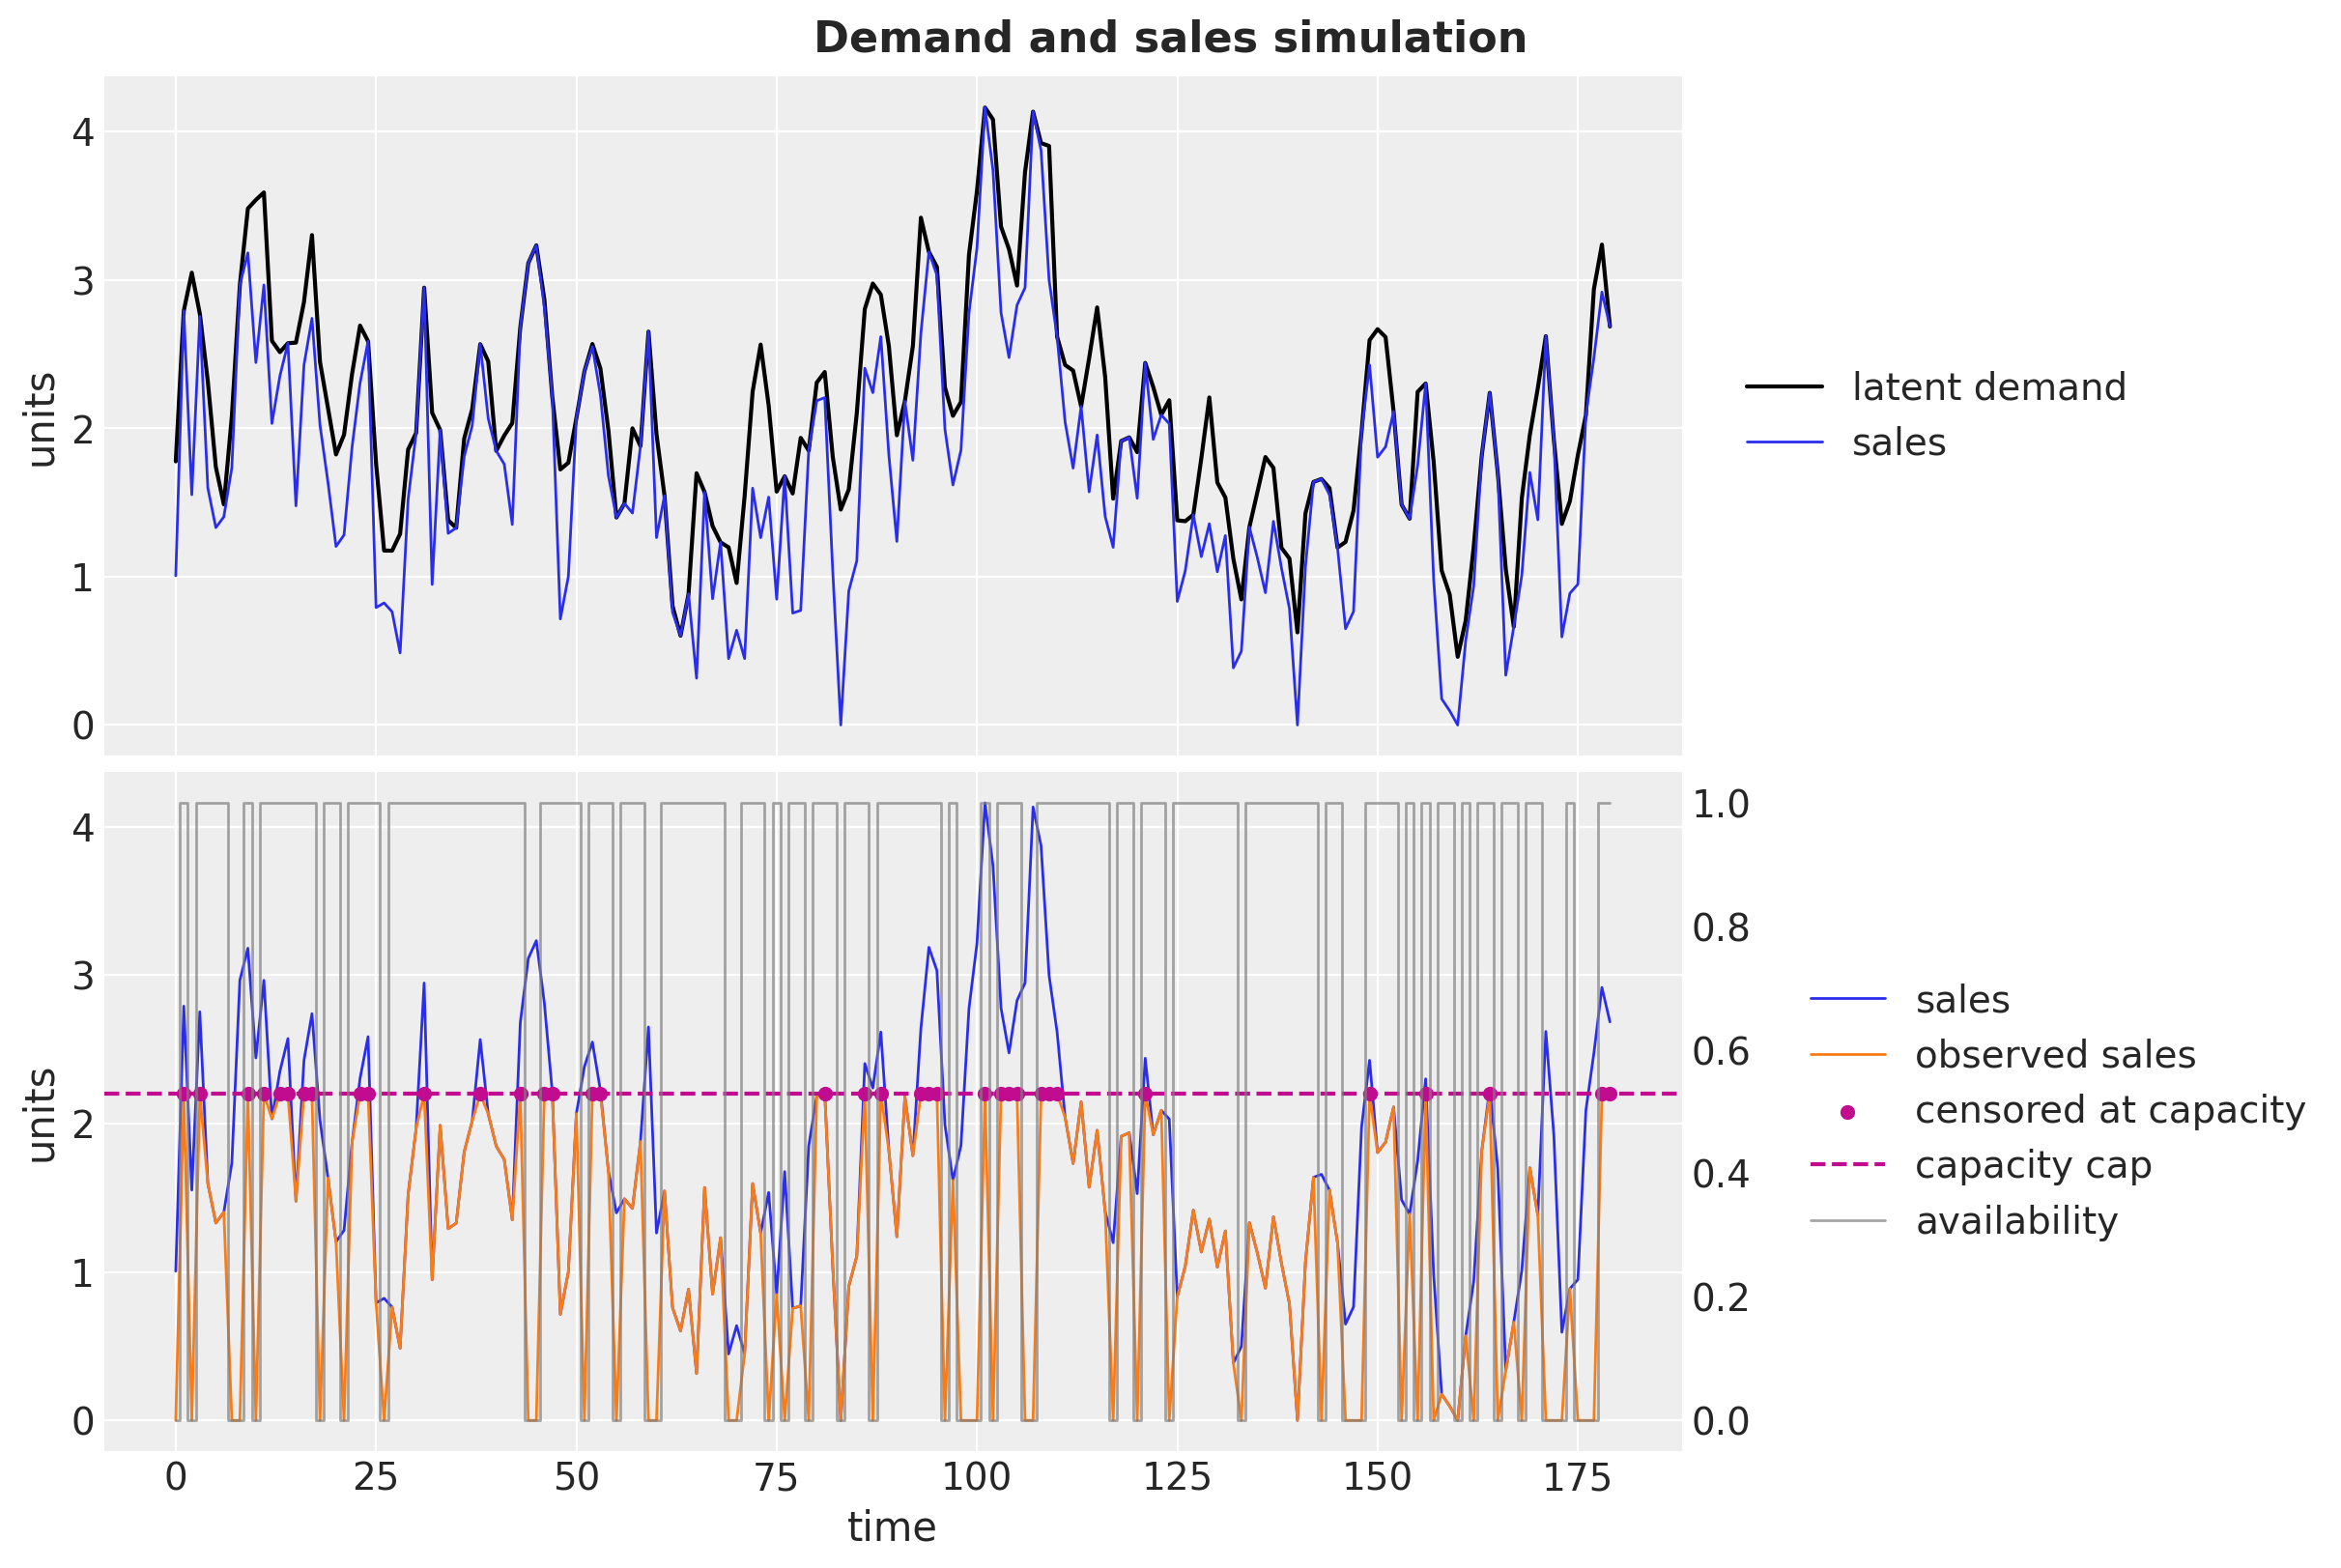

In [3]:
fig, (ax_top, ax_bot) = plt.subplots(
    nrows=2, ncols=1, sharex=True, sharey=True, figsize=(12, 8), layout="constrained"
)
ax_top.plot(time, np.asarray(demand), color="black", lw=1.5, label="latent demand")
ax_top.plot(time, np.asarray(sales), color="C0", lw=1, label="sales")
ax_top.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax_top.set(ylabel="units")

ax_bot.plot(time, np.asarray(sales), color="C0", lw=1, label="sales")
ax_bot.plot(time, np.asarray(sales_obs), color="C1", lw=1, label="observed sales")
ax_bot.scatter(
    time[np.asarray(censored) == 1],
    np.asarray(sales_obs)[np.asarray(censored) == 1],
    color="C3",
    s=20,
    zorder=5,
    label="censored at capacity",
)
ax_bot.axhline(params.max_capacity, color="C3", ls="--", lw=1.5, label="capacity cap")
ax_twin = ax_bot.twinx()
ax_twin.plot(
    time,
    np.asarray(is_available),
    color="gray",
    lw=1,
    alpha=0.7,
    drawstyle="steps-mid",
    label="availability",
)
ax_twin.grid(False)
bot_handles, bot_labels = ax_bot.get_legend_handles_labels()
twin_handles, twin_labels = ax_twin.get_legend_handles_labels()
ax_bot.legend(
    bot_handles + twin_handles,
    bot_labels + twin_labels,
    loc="center left",
    bbox_to_anchor=(1.06, 0.5),
)
ax_bot.set(xlabel="time", ylabel="units")
fig.suptitle("Demand and sales simulation", fontsize=16, fontweight="bold");

## Train-test split and covariates

We hold out the last $30$ days as the test window. Throughout the
package, time lives at axis `-2` and the observation dimension at axis
`-1`, so the training data has shape `(150, 1)`.

The covariates carry everything the model needs over the **full**
duration, in a `(180, 7)` tensor. The package infers the forecast
horizon from the shapes: covariates longer than the data by $30$ rows
means a $30$-step forecast.

- Column `0` is the observed sales history the AR recursion filters. The
  history has to travel through the covariates rather than the data
  argument: the package’s `predict_in_sample` and `to_datatree` call the
  model with `data=None` (they sample the observation site), while the
  recursion always needs the observed series. Only the first `t_obs`
  rows are ever read (the `ssoe` building block below checks this), so
  the future rows are zeroed out and no information leaks.
- Column `1` is the availability mask and column `2` the censoring
  indicator, read only over the training rows. One honest caveat versus
  the availability TSB and fresh retail examples, whose recursions
  consume these inputs over the horizon too: here the model pads its own
  horizon inputs (availability one, censoring zero), so the forecast is
  *structurally* uncensored demand-scale sales, the number a planner
  should order against, regardless of what the trailing rows contain. We
  still pin the trailing $30$ rows to the same values so the scenario
  travels with the forecast into the tree’s `predictions_constant_data`,
  as documentation rather than as a model input.
- Columns `3:7` are weekly Fourier features (two harmonics, sines then
  cosines) from the package’s
  [`fourier_features`](https://juanitorduz.github.io/numpyro_forecast/reference/features.fourier_features.html)
  helper, the only columns the model reads over the horizon.

In [4]:
forecast_horizon = 30
n_train = params.n_periods - forecast_horizon

train_data = sales_obs[:n_train][:, None]
demand_test = demand[n_train:][:, None]
sales_obs_test = sales_obs[n_train:][:, None]
t_test = time[n_train:]

n_order = 2
fourier = fourier_features(params.n_periods, float(params.seasonal_period), n_order)

in_train = jnp.arange(params.n_periods) < n_train
covariates = jnp.concatenate(
    [
        jnp.where(in_train, sales_obs, 0.0)[:, None],  # history; future rows never read
        jnp.where(in_train, is_available, 1.0)[:, None],  # scenario: fully available
        jnp.where(in_train, censored, 0.0)[:, None],  # scenario: uncensored
        fourier,
    ],
    axis=-1,
)
covariates_train = covariates[:n_train]
print(f"train data shape: {train_data.shape}, full covariates shape: {covariates.shape}")

train data shape: (150, 1), full covariates shape: (180, 7)

## Model specification

The mean recursion is an AR(2) on *filtered* lags $\tilde{y}_t$ (defined
below) plus a Fourier seasonal term:

$$\hat{y}_t = \mu + \phi_1 \, \tilde{y}_{t-1} + \phi_2 \, \tilde{y}_{t-2} + \mathbf{f}_t^\top \boldsymbol{\beta},$$

with priors

The likelihood is where the censoring lives. An uncensored day
contributes the usual density; a censored day only tells us that latent
sales were *at least* the cap, so it contributes the survival mass above
the recorded value:

$$p(y_t \mid \hat{y}_t, \sigma) = \text{Normal}(y_t \mid \hat{y}_t, \sigma)^{1 - c_t} \left[1 - \Phi\left(\frac{y_t - \hat{y}_t}{\sigma}\right)\right]^{c_t},$$

where $\Phi$ is the standard $\text{Normal}$ CDF, and the whole term is
masked out on stockout days ($a_t = 0$), which carry no demand
information. NumPyro ships this construction (from version `0.20.0`) as
[`RightCensoredDistribution`](https://num.pyro.ai/en/stable/distributions.html#censored-distributions):
its `log_prob` is exactly the expression above (with a
numerical-stability clip on the CDF), and its `sample` draws from the
*uncensored* base distribution, which is precisely what we want
posterior predictive draws to describe. The whole likelihood is then a
single vectorized `"obs"` site.

**Filtering through the gaps.** Masking the likelihood is only half the
treatment of a corrupted day, because an autoregression also consumes
every day as a *lagged value*. A recorded stockout zero fed into the
carry masquerades as a demand crash: it drags the next day’s prediction
down, attenuates the AR coefficients (post-gap days look like violent
rebounds no moderate $\phi$ can explain), and inflates $\sigma$ to
absorb the damage. The recursion therefore carries a filtered series
instead of the raw observations:

$$\tilde{y}_t = a_t \left[(1 - c_t) \, y_t + c_t \max\left(y_t, \hat{y}_t\right)\right] + (1 - a_t) \, \hat{y}_t.$$

Clean on-shelf days pass the observation through; capped days floor the
lag at the model’s own prediction, since the truth is at least the cap;
off-shelf days carry the prediction itself, the model’s best estimate of
the demand nobody could express. This is the same one-step-ahead logic a
state space filter applies to missing observations, done with a plug-in
mean instead of a full state distribution.

The model is a plain NumPyro function `(covariates, data=None)` that
derives its train/forecast split from the shapes with
[`Horizon.from_data`](https://juanitorduz.github.io/numpyro_forecast/reference/models.Horizon.html)
and hands the recursion to the
[`ssoe`](https://juanitorduz.github.io/numpyro_forecast/reference/models.ssoe.html)
building block, the single-source-of-error recursion shared with the
[ARMA](https://juanitorduz.github.io/numpyro_forecast/examples/arma.html)
and [exponential
smoothing](https://juanitorduz.github.io/numpyro_forecast/examples/exponential_smoothing_state_space.html)
examples. `ssoe` takes the driving series, an initial carry, a `step`
function, and the innovation distribution. `step(carry, x_t)` returns
the one-step-ahead mean $\hat{y}_t$ and a `carry_fn(y_t, eps_t)` that
builds the next carry from the day’s value and its error; closing
`carry_fn` over the prediction is what lets the lag filter above floor
capped days at $\hat{y}_t$. Rows carry the observation axis, so the two
placeholder lags are `y[0]` with shape `(1,)`, the mean has shape
`(1,)`, and a scalar state would emit `mu[None]`; the block checks these
shapes. The block owns two scans, neither containing a sample site:

1.  **In sample.** A deterministic `jax.lax.scan` runs `step` over the
    observed history, feeding each observation and its error
    $\varepsilon_t = y_t - \hat{y}_t$ through `carry_fn`, and returns
    the one-step-ahead means as `r.mu` (exposed as the deterministic
    site `"pred_mean"`); the `"obs"` site conditions the data on them
    through the censored likelihood. The AR(2) needs two lags, so the
    first two steps run on placeholder lags and are masked out of the
    likelihood.
2.  **Out of sample.** When `h.future > 0` the block draws the horizon
    innovations at the `"eps_future"` site (under its own `time_future`
    plate), rolls the recursion forward from the final filtered lags
    with each *sampled* value $\hat{y}_t + \varepsilon_t$ fed back
    through `carry_fn`, and returns the trajectory as `r.y_future`,
    which we register (clipped at zero, since demand is nonnegative) as
    the deterministic `"forecast"` site the package reads. Since
    `"eps_future"` does not exist during training, `Predictive` draws it
    from the prior at forecast time and the uncertainty compounds over
    the horizon exactly as the generative process says it should. The
    availability and censoring inputs are padded over the horizon with
    [`pad_future`](https://juanitorduz.github.io/numpyro_forecast/reference/arrays.pad_future.html)
    (available, uncensored), so no gate or cap applies there: the
    forecast is of latent demand-scale sales, unconstrained by the cap.

One small difference from the blog post’s hand-rolled scans: the same
`carry_fn` serves both scans, so the clip at zero now applies to the
filtered lag in sample as well, which only matters on stockout days
whose prediction is negative.

In [5]:
def ar2_seasonal(covariates: Array, data: Array | None = None) -> None:
    """Censored AR(2) model with weekly Fourier seasonality.

    Parameters
    ----------
    covariates
        Seven-input tensor ``(duration, 7)`` spanning the full horizon: column
        ``0`` is the observed sales history (only the first ``h.t_obs`` rows
        are read), column ``1`` the availability mask, column ``2`` the
        censoring indicator, and columns ``3:7`` the weekly Fourier features
        (the only columns read over the forecast horizon).
    data
        Observed sales with time at axis ``-2``, or ``None`` when the drivers
        sample the observation site.
    """
    h = Horizon.from_data(covariates, data)
    y = covariates[..., : h.t_obs, 0:1]  # observed history only; never reads beyond t_obs
    available = covariates[..., : h.t_obs, 1:2]
    censored = covariates[..., : h.t_obs, 2:3]
    fourier = covariates[..., 3:]

    mu = numpyro.sample("mu", dist.Normal(loc=1, scale=1))
    phi_1 = numpyro.sample("phi_1", dist.Normal(loc=0, scale=1))
    phi_2 = numpyro.sample("phi_2", dist.Normal(loc=0, scale=1))
    sigma = numpyro.sample("sigma", dist.HalfNormal(scale=1))
    with numpyro.plate("fourier_modes", fourier.shape[-1]):
        # jnp.asarray only narrows numpyro's union return type for the type checker.
        beta_seasonal = jnp.asarray(numpyro.sample("beta_seasonal", dist.Normal(loc=0, scale=1)))
    seasonal = (fourier @ beta_seasonal)[..., None]

    def step(carry, x_t):
        seasonal_t, available_t, censored_t = x_t
        lag_1, lag_2 = carry
        pred = mu + phi_1 * lag_1 + phi_2 * lag_2 + seasonal_t

        def carry_fn(y_t, _):
            # The filtered lag: pass clean observations through, floor capped days at the
            # prediction, and substitute the prediction on stockout days.
            on_shelf = jnp.where(censored_t == 1, jnp.maximum(y_t, pred), y_t)
            y_filtered = jnp.where(available_t == 1, on_shelf, pred)
            return jnp.clip(y_filtered, min=0.0), lag_1

        return pred, carry_fn

    # Over the horizon the product is available and uncensored: no gate, no cap.
    xs = (seasonal, pad_future(available, h.future, value=1.0), pad_future(censored, h.future))
    init_carry = (y[0], y[0])  # placeholder lags; the first two steps are masked below
    r = ssoe(h, "eps", y, init_carry, step, dist.Normal(loc=0, scale=sigma), xs=xs)
    pred_mean = numpyro.deterministic("pred_mean", r.mu)

    valid = (jnp.arange(h.t_obs)[:, None] >= 2) & (available == 1)
    numpyro.sample(
        "obs",
        dist.RightCensoredDistribution(
            dist.Normal(loc=pred_mean, scale=sigma), censored=censored
        ).mask(valid),
        obs=h.data,
    )
    if h.future > 0:
        numpyro.deterministic("forecast", jnp.clip(r.y_future, min=0.0))

## Inference with NUTS

We fit the model on the training window with plain NumPyro: the
No-U-Turn Sampler through `MCMC`, running $4$ chains of $1{,}000$ warmup
and $1{,}000$ sampling steps each with `target_accept_prob=0.9` (the
survival term gives the likelihood a slightly harder geometry near the
cap). A modest budget is plenty because the posterior is tiny: the
in-sample filter is deterministic, so the only latents are the eight
parameters ($\mu$, $\phi_1$, $\phi_2$, $\sigma$, and four Fourier
coefficients). The small `fit_nuts` helper wraps the call so the naive
baseline below fits with exactly the same settings.

We then export the posterior draws into an ArviZ-schema
`xarray.DataTree` with
[`to_datatree`](https://juanitorduz.github.io/numpyro_forecast/reference/convert.to_datatree.html),
which restores the `(chain, draw)` structure (we pass `num_chains=4`)
and samples the in-sample posterior predictive from the same draws.
Because we pass the *extended* covariates, the tree automatically
carries `predictions` groups with the out-of-sample draws of the
`"forecast"` site, and the trailing scenario rows of the covariates land
verbatim in `predictions_constant_data`, so the tree documents that this
forecast describes a full-availability, uncensored scenario.

In [6]:
def fit_nuts(
    rng_key: Array, model: ForecastModel, data: Array, covariates: Array
) -> dict[str, Array]:
    """Fit ``model`` with NUTS at ``target_accept_prob=0.9`` (4 chains, 1,000 warmup and 1,000 draws each)."""
    mcmc = MCMC(
        NUTS(model, target_accept_prob=0.9),
        num_warmup=1_000,
        num_samples=1_000,
        num_chains=4,
        chain_method="sequential",
        progress_bar=False,
    )
    mcmc.run(rng_key, covariates, data)
    return mcmc.get_samples()


rng_key, rng_subkey = random.split(rng_key)
posterior = fit_nuts(rng_subkey, ar2_seasonal, train_data, covariates_train)

rng_key, rng_subkey = random.split(rng_key)
tree = to_datatree(
    rng_subkey,
    ar2_seasonal,
    posterior,
    train_data,
    covariates,
    num_chains=4,
    posterior_dims={"pred_mean": ["time", "obs_dim"]},
)
tree

<xarray.DataTree>
Group: /
│ Attributes:
│ inference_library: numpyro
│ creation_library: numpyro_forecast
│ sample_dims: ['chain', 'draw']
├── Group: /posterior
│ Dimensions: (chain: 4, draw: 1000, beta_seasonal_dim_0: 4,
│ time: 150, obs_dim: 1)
│ Coordinates:
│ * chain (chain) int64 32B 0 1 2 3
│ * draw (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│ * beta_seasonal_dim_0 (beta_seasonal_dim_0) int64 32B 0 1 2 3
│ * time (time) int64 1kB 0 1 2 3 4 5 ... 145 146 147 148 149
│ * obs_dim (obs_dim) int64 8B 0
│ Data variables:
│ beta_seasonal (chain, draw, beta_seasonal_dim_0) float32 64kB 0.58...
│ mu (chain, draw) float32 16kB 0.3005 0.1796 ... 0.5165
│ phi_1 (chain, draw) float32 16kB 0.4918 0.5269 ... 0.55
│ phi_2 (chain, draw) float32 16kB 0.3845 0.4196 ... 0.2187
│ pred_mean (chain, draw, time, obs_dim) float32 2MB 0.04996 ......
│ sigma (chain, draw) float32 16kB 0.4969 0.521 ... 0.5858
│ Attributes:
│ created_at: 2026-08-26T16:34:49.569693+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.3.0
│ creation_library_language: Python
│ sample_dims: ['chain', 'draw']
├── Group: /posterior_predictive
│ Dimensions: (chain: 4, draw: 1000, time: 150, obs_dim: 1)
│ Coordinates:
│ * chain (chain) int64 32B 0 1 2 3
│ * draw (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│ * time (time) int64 1kB 0 1 2 3 4 5 6 7 ... 143 144 145 146 147 148 149
│ * obs_dim (obs_dim) int64 8B 0
│ Data variables:
│ obs (chain, draw, time, obs_dim) float32 2MB -0.5638 0.9075 ... 2.377
│ Attributes:
│ created_at: 2026-08-26T16:34:49.714707+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.3.0
│ creation_library_language: Python
│ sample_dims: ['chain', 'draw']
├── Group: /observed_data
│ Dimensions: (time: 150, obs_dim: 1)
│ Coordinates:
│ * time (time) int64 1kB 0 1 2 3 4 5 6 7 ... 143 144 145 146 147 148 149
│ * obs_dim (obs_dim) int64 8B 0
│ Data variables:
│ obs (time, obs_dim) float32 600B 0.0 2.2 0.0 2.2 ... 0.0 0.0 0.0 2.2
│ Attributes:
│ created_at: 2026-08-26T16:34:49.714958+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.3.0
│ creation_library_language: Python
│ sample_dims: []
├── Group: /constant_data
│ Dimensions: (time: 150, covariate_dim: 7)
│ Coordinates:
│ * time (time) int64 1kB 0 1 2 3 4 5 6 ... 144 145 146 147 148 149
│ * covariate_dim (covariate_dim) int64 56B 0 1 2 3 4 5 6
│ Data variables:
│ covariates (time, covariate_dim) float32 4kB 0.0 0.0 ... -0.2225 -0.901
│ Attributes:
│ created_at: 2026-08-26T16:34:49.715120+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.3.0
│ creation_library_language: Python
│ sample_dims: []
├── Group: /predictions
│ Dimensions: (chain: 4, draw: 1000, time: 30, obs_dim: 1)
│ Coordinates:
│ * chain (chain) int64 32B 0 1 2 3
│ * draw (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│ * time (time) int64 240B 150 151 152 153 154 155 ... 175 176 177 178 179
│ * obs_dim (obs_dim) int64 8B 0
│ Data variables:
│ obs (chain, draw, time, obs_dim) float32 480kB 2.964 1.631 ... 3.133
│ Attributes:
│ created_at: 2026-08-26T16:34:49.903397+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.3.0
│ creation_library_language: Python
│ sample_dims: ['chain', 'draw']
└── Group: /predictions_constant_data
 Dimensions: (time: 30, covariate_dim: 7)
 Coordinates:
 * time (time) int64 240B 150 151 152 153 154 ... 175 176 177 178 179
 * covariate_dim (covariate_dim) int64 56B 0 1 2 3 4 5 6
 Data variables:
 covariates (time, covariate_dim) float32 840B 0.0 1.0 ... -0.901 0.6235
 Attributes:
 created_at: 2026-08-26T16:34:49.903610+00:00
 creation_library: ArviZ
 creation_library_version: 1.3.0
 creation_library_language: Python
 sample_dims: [] xarray.DataTree /posterior (16) Dimensions: chain : 4 draw : 1000 beta_seasonal_dim_0 : 4 time : 150 obs_dim : 1 Coordinates: (5) chain (chain) int64 0 1 2 3 array([0, 1, 2, 3]) draw (draw) int64 0 1 2 3 4 5 ... 995 996 997 998 999 array([ 0, 1, 2, ..., 997, 998, 999], shape=(1000,)) beta_

## Diagnostics

`az.summary` on the parameters gives the convergence picture in one
call: posterior means and standard deviations, the $94\%$ HDIs,
effective sample sizes, and $\hat{R}$.

A word on reading the parameter table: the data generating process used
$\phi_1 = 0.6$, $\phi_2 = 0.3$, and intercept $0.2$. Exact recovery is
not on the table, because the model’s recursion runs on (filtered) sales
rather than demand and the process clips at zero, but the estimates land
in the right neighborhood, and they do so *because of* the lag filter.
Feed the recorded stockout zeros in as lagged values instead and the AR
coefficients collapse toward zero while $\sigma$ inflates: every
post-stockout day then looks like a violent rebound from a demand crash
that never happened, and shrinking $\phi$ is the likelihood’s only way
to explain it. The forecast quality check that ultimately matters,
recovering latent demand out of sample, comes further below.

In [7]:
scalar_vars = ["mu", "phi_1", "phi_2", "sigma", "beta_seasonal"]
az.summary(tree, var_names=scalar_vars, ci_kind="hdi", ci_prob=0.94)

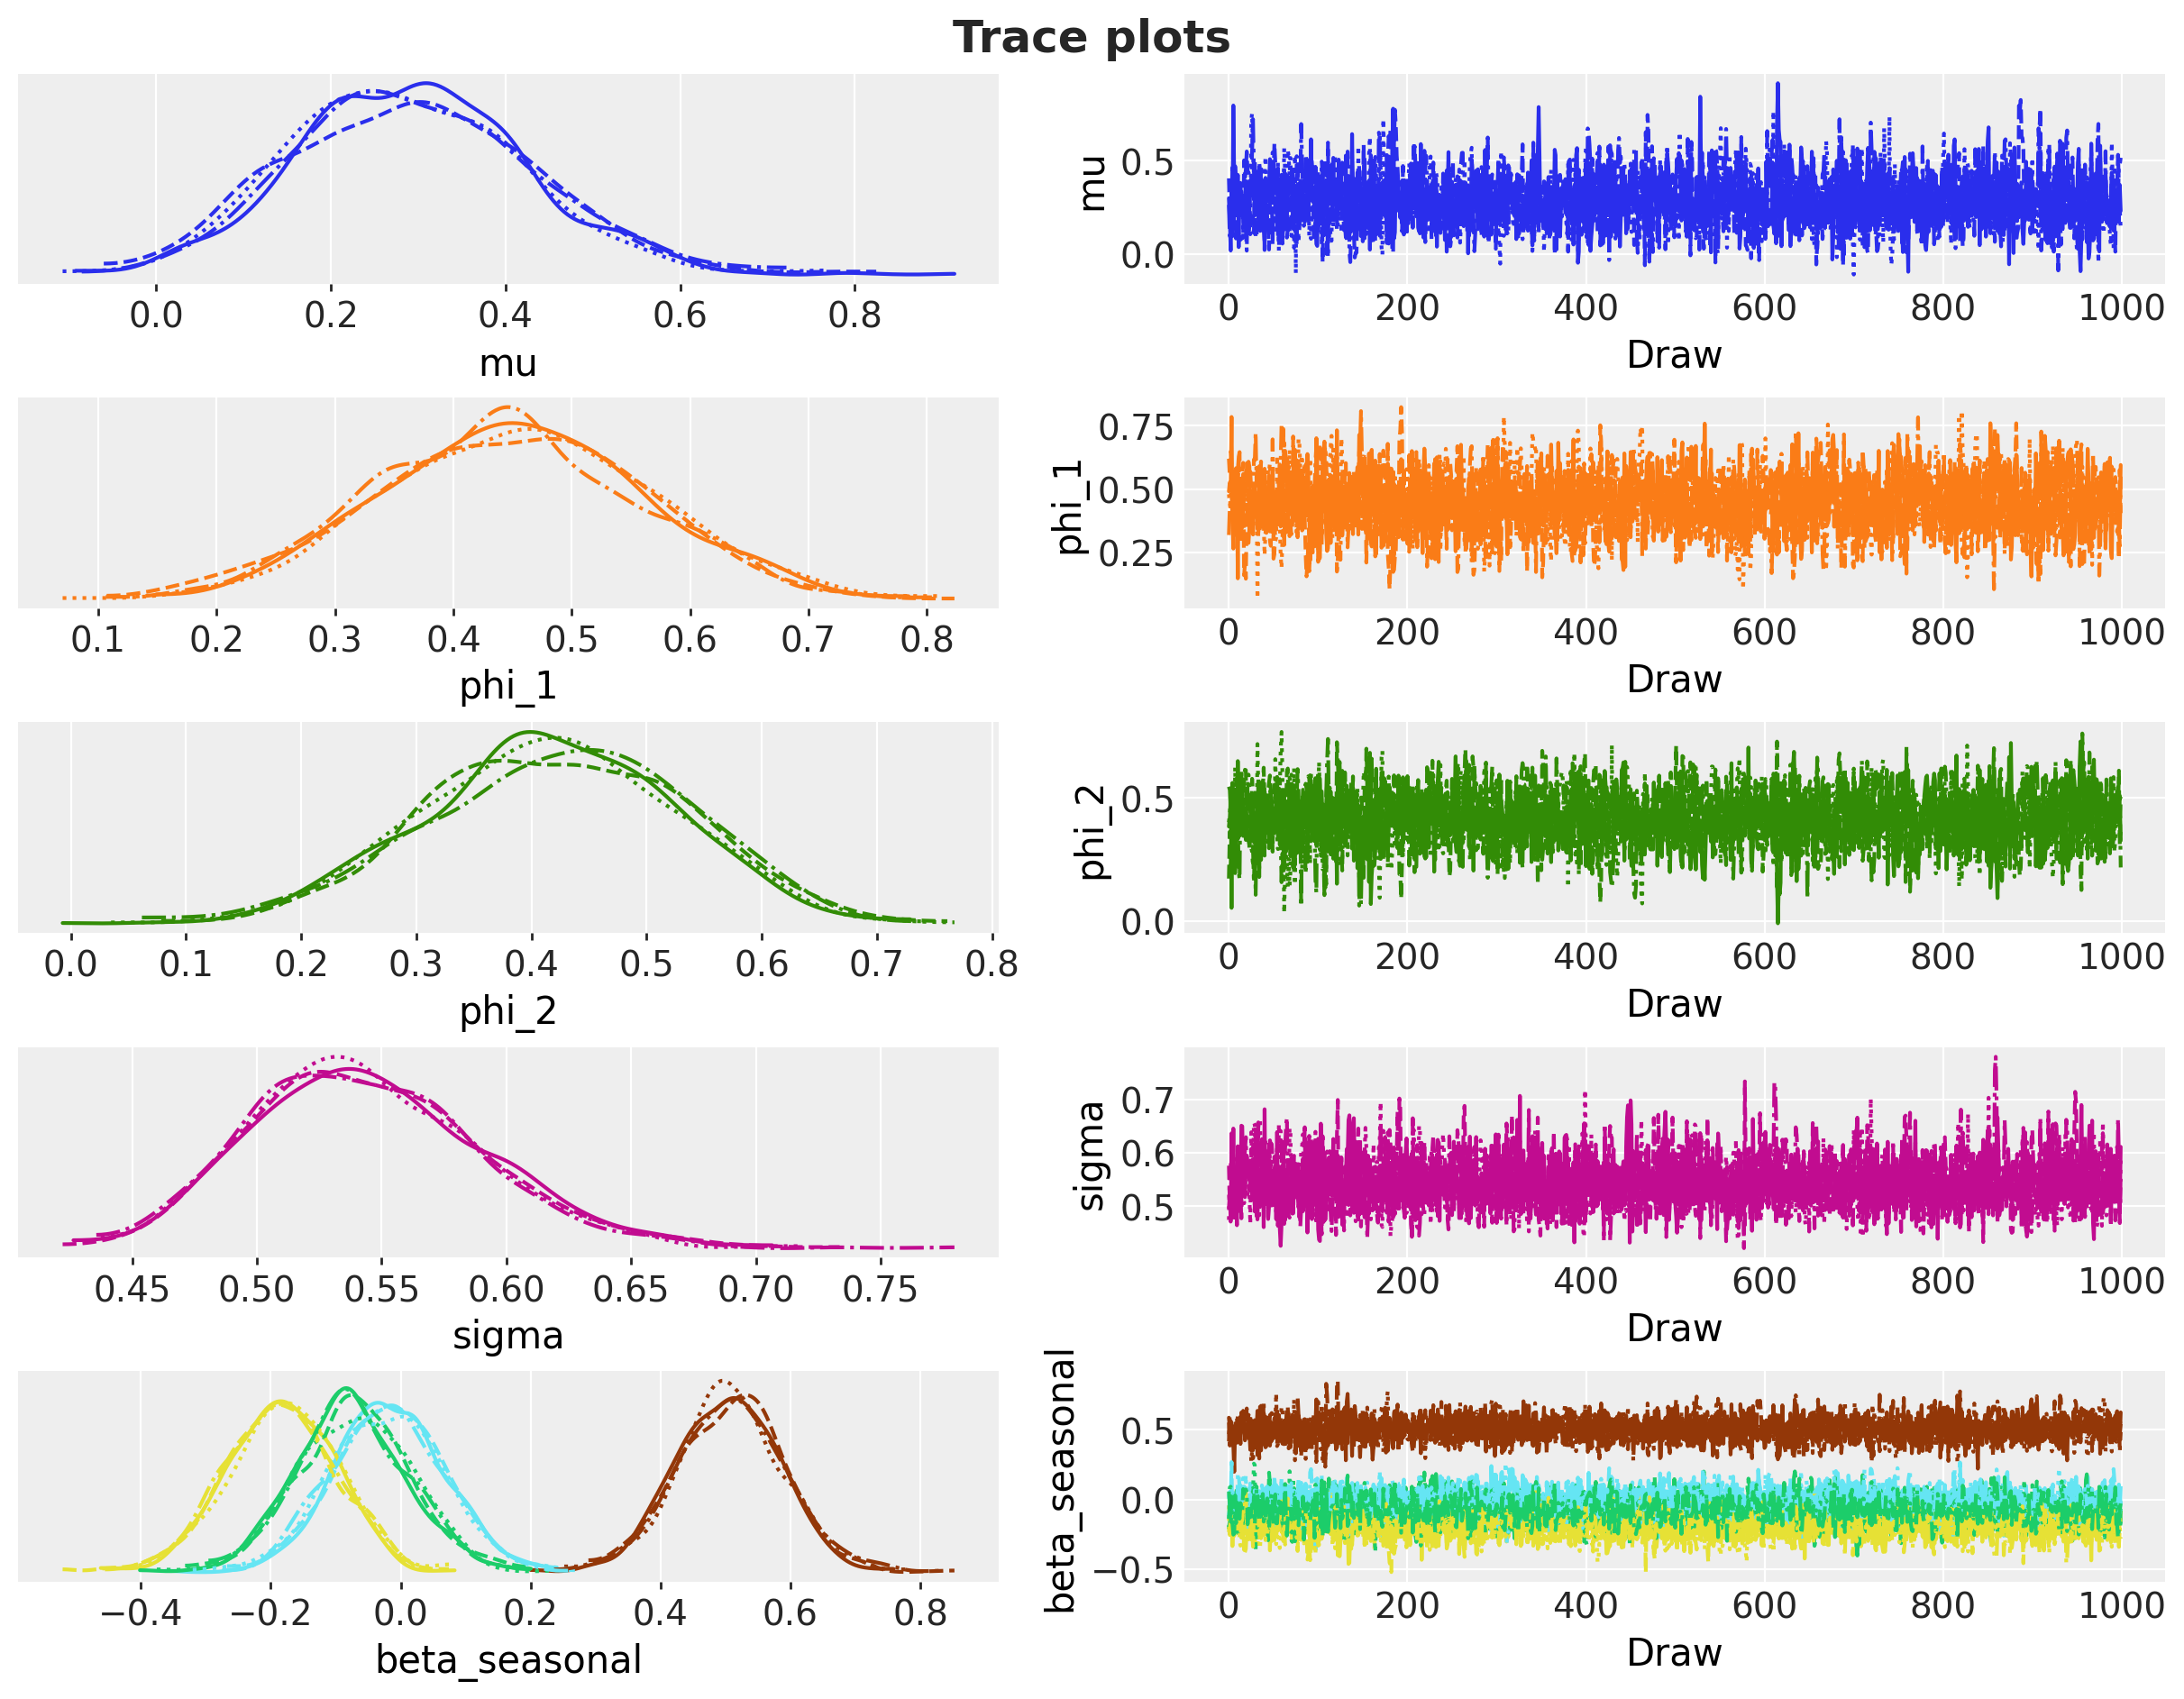

In [8]:
pc_trace = az.plot_trace_dist(
    tree,
    var_names=scalar_vars,
    compact=True,
    figure_kwargs={"figsize": (12, 9)},
)
pc_trace.viz["figure"].item().suptitle(
    "Trace plots",
    fontsize=18,
    fontweight="bold",
    y=1.03,
);

## In-sample fit

The tree’s `posterior_predictive` group holds the one-step-ahead
predictive of the `"obs"` site over the training window (the first two
steps run on placeholder lags and are dropped from the plot). Because
`RightCensoredDistribution` samples from its *base* distribution, these
draws describe latent demand-scale sales, so the two places where they
deliberately disagree with the observed series are the whole point: on
capacity days the bands ride **above** the dashed cap that pins the
orange line down, and through the gray stockout gaps the predictive mean
carries the filter’s demand estimate instead of chasing the recorded
zeros. The latent demand curve (black), which the model never saw, runs
along the upper half of the bands (the predictive describes *sales*,
which sit below demand by the friction term) and escapes them only at
the strongest peaks. The lower band also dips below zero in the troughs:
a $\text{Normal}$ likelihood pays for its simplicity with predictive
mass on negative sales, a compromise the next steps revisit (the
forecast recursion, by contrast, clips its sampled trajectories at
zero). This cell also defines the small plotting helpers
(`stacked_draws` and `plot_band_forecast`) shared with the remaining
band plots.

/Users/juanitorduz/Documents/numpyro_forecast/.claude/worktrees/refactor3-pr-e1/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(

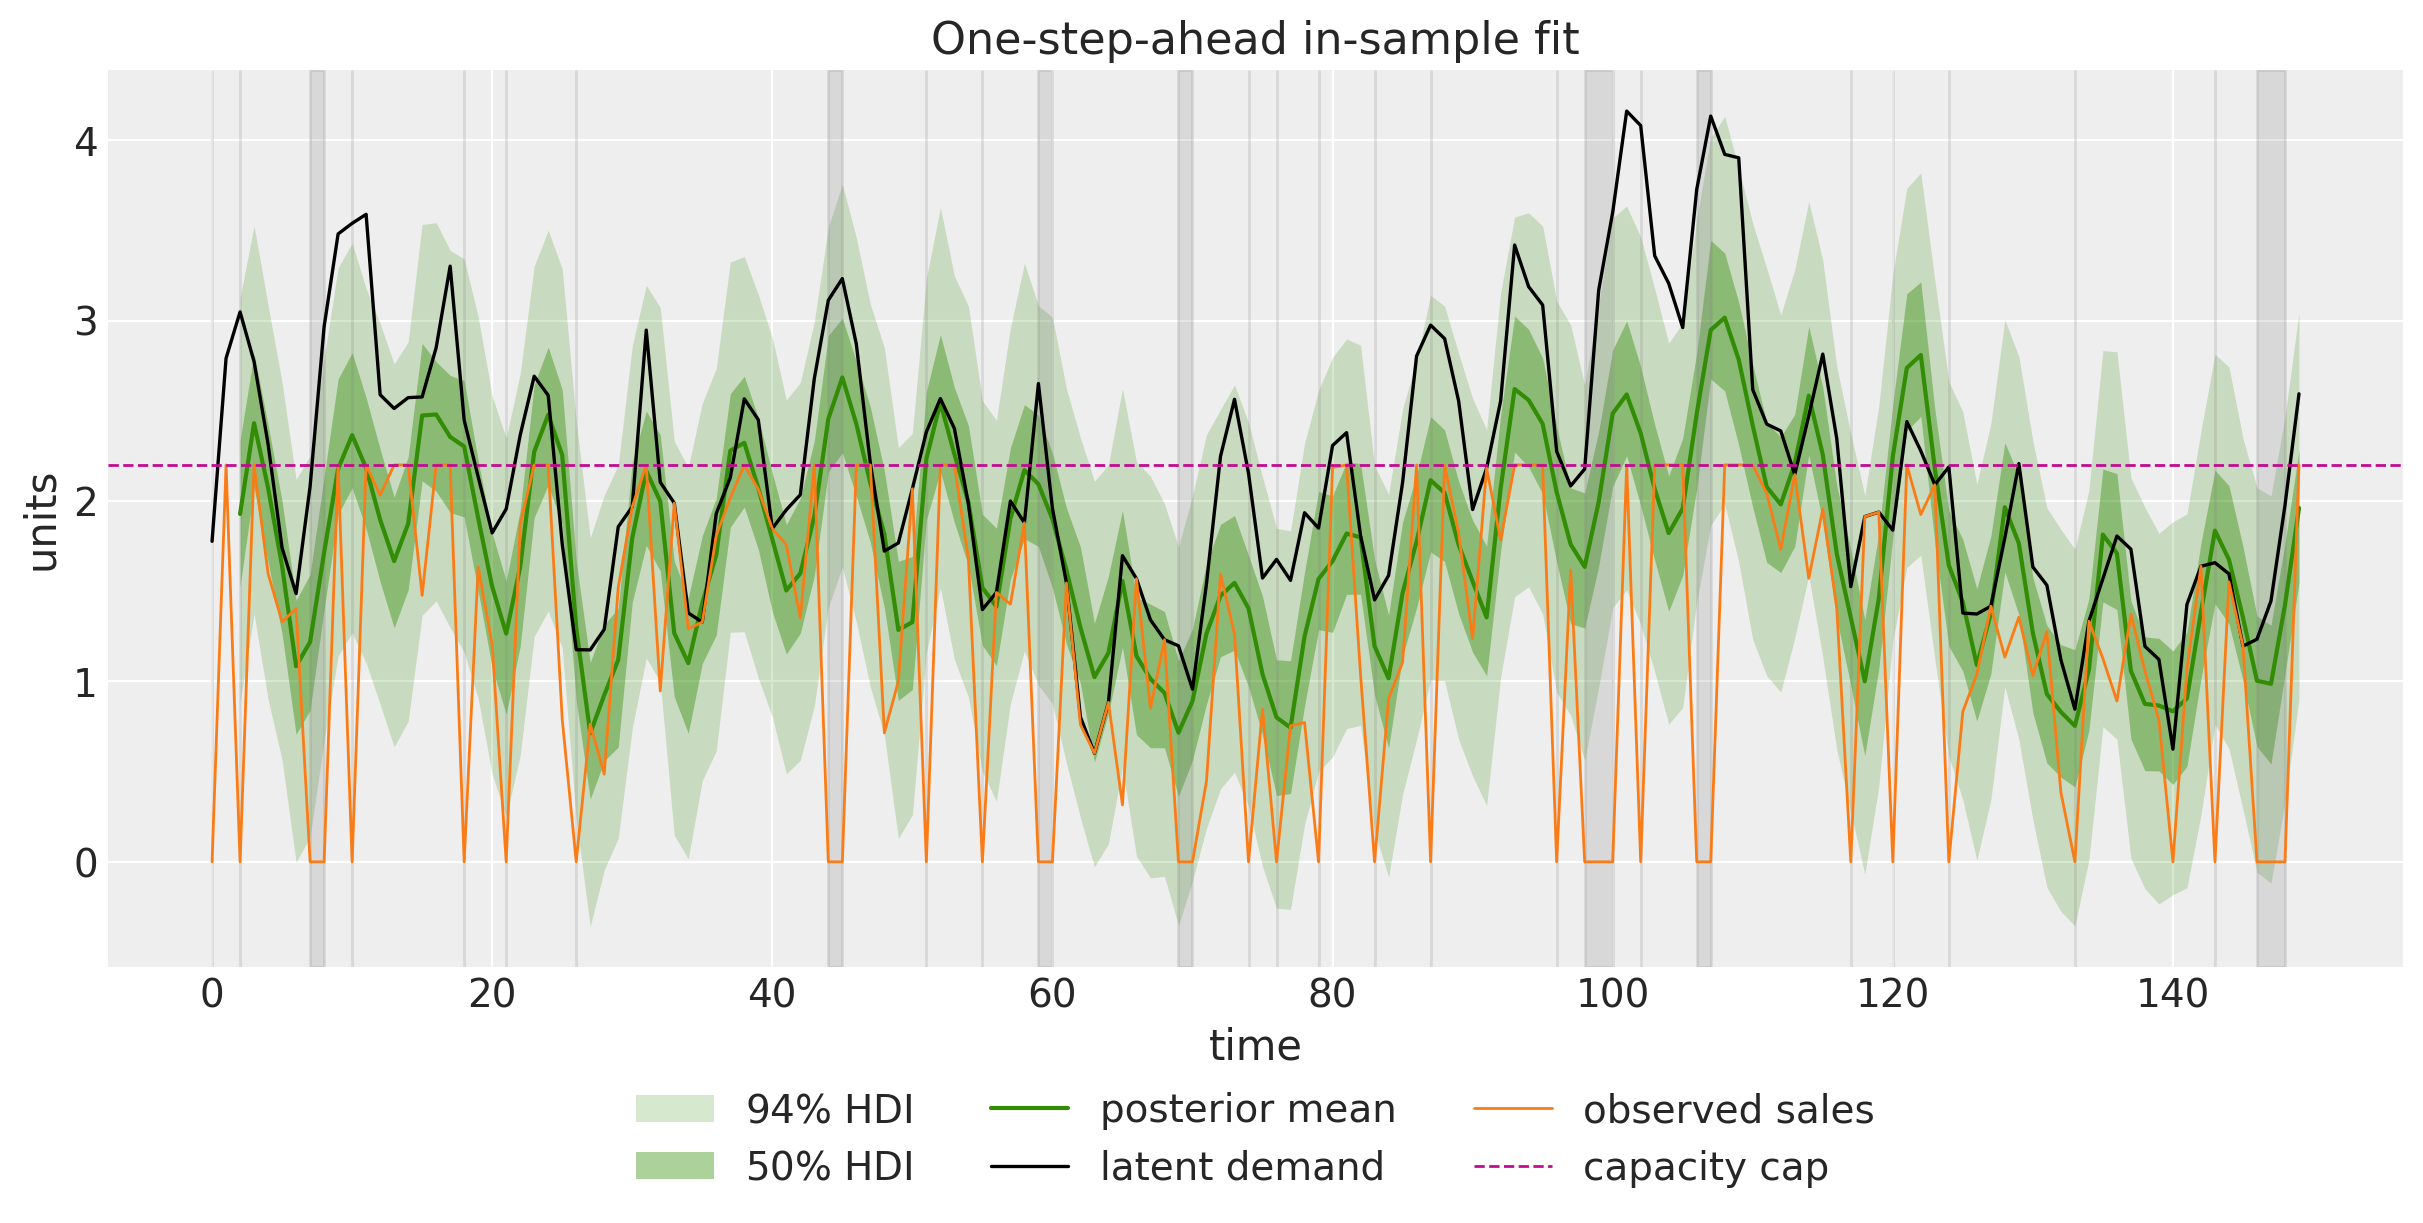

In [9]:
def hdi_label(prob: float, prefix: str = "") -> str:
    r"""Legend label for an HDI band, e.g. ``$94\%$ HDI``."""
    percent = f"{prob:.0%}".replace("%", r"\%")
    return f"{prefix}${percent}$ HDI"


hdi_probs = (0.5, 0.94)
hdi_alphas = [0.4, 0.2]  # 50% band darker, 94% band lighter; both light enough to read overlays


def stacked_draws(group: xr.DataTree | xr.DataArray, var: str) -> np.ndarray:
    """Stack a tree variable's ``(chain, draw)`` dims into a leading sample axis.

    Parameters
    ----------
    group
        A tree group holding ``var`` with dims ``(chain, draw, time, obs_dim)``
        (typed as the union ``tree[...]`` returns; a group always arrives here).
    var
        Name of the variable to extract.

    Returns
    -------
    np.ndarray
        The draws with shape ``(sample, time, obs_dim)``.
    """
    return (
        group.dataset[var]
        .stack(sample=("chain", "draw"))
        .transpose("sample", "time", "obs_dim")
        .to_numpy()
    )


def plot_band_forecast(
    draws: np.ndarray,
    x: np.ndarray,
    color: str,
    label_prefix: str = "",
    observed: Array | np.ndarray | None = None,
    figsize: tuple[float, float] = (12.0, 6.0),
) -> tuple[Axes, list[Artist]]:
    r"""Plot the posterior mean line and the $50\%$/$94\%$ HDI bands of ``draws``.

    Wraps ``predictions_to_datatree`` and ``az.plot_lm`` with the notebook-wide
    band styling (inner band darker via ``hdi_alphas``) and labels the artists.
    Overlays (observed series, split lines, extra reference lines) and the
    legend are the caller's responsibility.

    Parameters
    ----------
    draws
        Predictive draws with shape ``(sample, time, 1)``.
    x
        Numeric x values of length ``time``.
    color
        Matplotlib color for the bands and the mean line.
    label_prefix
        Prefix for the legend labels, e.g. ``"forecast "``.
    observed
        Optional observed data stored alongside the draws.
    figsize
        Figure size passed to ``plot_lm``.

    Returns
    -------
    tuple[Axes, list[Artist]]
        The axes and the labeled band and mean-line handles for the legend.
    """
    idata = predictions_to_datatree(draws, x, ["y"], observed=observed)
    pc = az.plot_lm(
        idata,
        y="obs",
        x="t",
        plot_dim="time",
        ci_kind="hdi",
        ci_prob=hdi_probs,
        smooth=False,
        point_estimate="mean",
        visuals={
            "ci_band": {"color": color},
            "observed_scatter": False,
            "pe_line": {"color": color, "alpha": 1.0, "width": 1.5},
        },
        aes={"alpha": ["prob"]},
        alpha=hdi_alphas,
        figure_kwargs={"figsize": figsize},
    )
    bands = pc.viz["ci_band"]["t"]
    band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
    band_94.set_label(hdi_label(0.94, prefix=label_prefix))
    band_50.set_label(hdi_label(0.5, prefix=label_prefix))
    pe_line = pc.viz["pe_line"]["t"].item()
    pe_line.set_label(f"{label_prefix}posterior mean")
    ax = pc.viz["figure"].item().axes[0]
    return ax, [band_94, band_50, pe_line]


train_pp = stacked_draws(tree["posterior_predictive"], "obs")[:, 2:, :]

ax, handles = plot_band_forecast(
    train_pp,
    time[2:n_train].astype(float),
    "C2",
    observed=train_data[2:],
)
ax.fill_between(
    time[:n_train],
    0,
    1,
    where=(np.asarray(is_available[:n_train]) == 0).tolist(),
    transform=ax.get_xaxis_transform(),
    color="gray",
    alpha=0.2,
    step="mid",
)
(demand_line,) = ax.plot(
    time[:n_train], np.asarray(demand[:n_train]), color="black", lw=1.2, label="latent demand"
)
(obs_line,) = ax.plot(
    time[:n_train], np.asarray(sales_obs[:n_train]), color="C1", lw=1, label="observed sales"
)
cap_line = ax.axhline(params.max_capacity, color="C3", ls="--", lw=1, label="capacity cap")
ax.legend(
    handles=[*handles, demand_line, obs_line, cap_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(title="One-step-ahead in-sample fit", xlabel="time", ylabel="units");

## Forecasting demand

The `predictions` group already holds the out-of-sample draws of the
`"forecast"` site, structurally uncensored as discussed in the
covariates section. We plot them against the **latent demand**, the
series the model never saw, and score the forecast with the CRPS against
that ground truth.

This is the money plot of the example: on its seasonal peaks the demand
runs above the capacity cap, into territory where not a single
observation exists, and the forecast mean follows it across the line. A
model of *sales* cannot do this, because sales above the cap were never
once recorded; the survival terms in the likelihood are what taught the
model that capped days were floors, not values.

/Users/juanitorduz/Documents/numpyro_forecast/.claude/worktrees/refactor3-pr-e1/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(

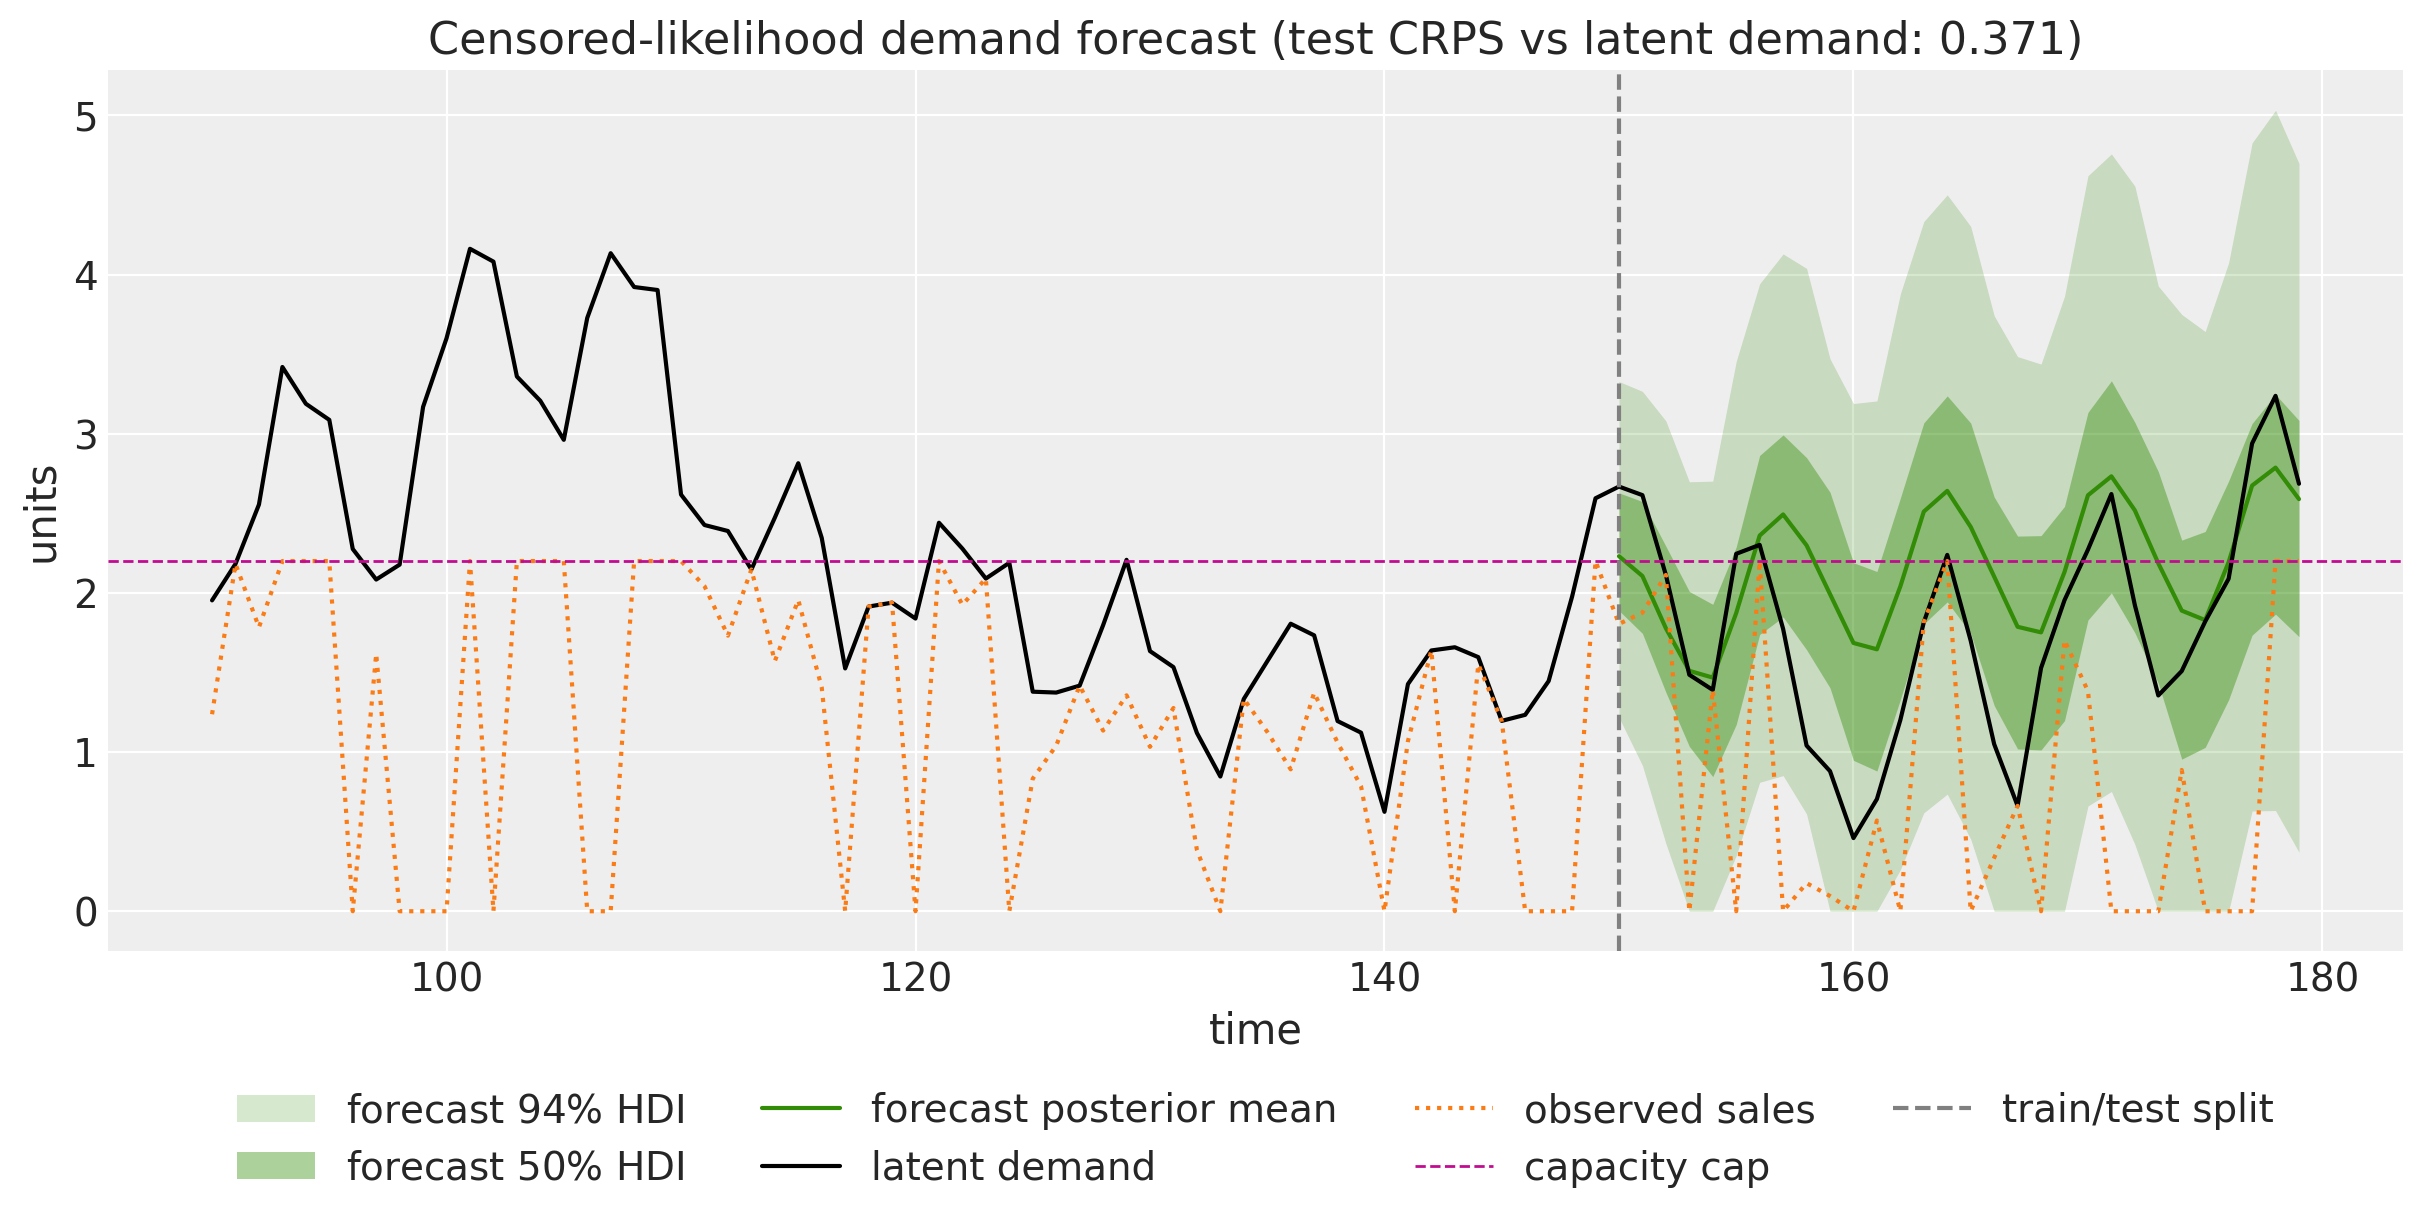

In [10]:
forecast_pp = stacked_draws(tree["predictions"], "obs")
crps_demand = eval_crps(forecast_pp, demand_test)

t_zoom = time[90:]
ax, handles = plot_band_forecast(forecast_pp, t_test.astype(float), "C2", label_prefix="forecast ")
(demand_line,) = ax.plot(
    t_zoom, np.asarray(demand[90:]), color="black", lw=1.5, label="latent demand"
)
(sales_line,) = ax.plot(
    t_zoom, np.asarray(sales_obs[90:]), ":", color="C1", lw=1.5, label="observed sales"
)
cap_line = ax.axhline(params.max_capacity, color="C3", ls="--", lw=1, label="capacity cap")
split_line = ax.axvline(n_train, color="gray", ls="--", label="train/test split")
ax.legend(
    handles=[*handles, demand_line, sales_line, cap_line, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
)
ax.set(
    title=f"Censored-likelihood demand forecast (test CRPS vs latent demand: {crps_demand:.3f})",
    xlabel="time",
    ylabel="units",
);

## The naive comparison: ignoring the cap

How much of that is the censored likelihood, and how much just the AR(2)
structure? With the censoring indicator at zero everywhere,
`RightCensoredDistribution` *is* the plain $\text{Normal}$: every capped
day is treated as an exact observation of $2.2$. So the naive baseline
is the same model fit on a covariates tensor whose censoring column is
zeroed, one line of code. Stockout days remain masked and lag-filtered
in both models; what changes is only how the capacity days enter, in the
likelihood (exact value versus survival mass) and in the lag filter
(trusted versus floored at the prediction).

In [11]:
covariates_naive = covariates.at[:, 2].set(0.0)

rng_key, rng_subkey = random.split(rng_key)
posterior_naive = fit_nuts(rng_subkey, ar2_seasonal, train_data, covariates_naive[:n_train])

rng_key, rng_subkey = random.split(rng_key)
tree_naive = to_datatree(
    rng_subkey,
    ar2_seasonal,
    posterior_naive,
    train_data,
    covariates_naive,
    num_chains=4,
    posterior_dims={"pred_mean": ["time", "obs_dim"]},
)
az.summary(tree_naive, var_names=scalar_vars, ci_kind="hdi", ci_prob=0.94)

Side by side, the two forecasts tell the whole story. The censored model
tracks the latent demand above the cap; the naive model, trained to
believe demand *was* $2.2$ on every capped day, pulls its level down
toward the cap and undershoots the demand it is supposed to inform.

/Users/juanitorduz/Documents/numpyro_forecast/.claude/worktrees/refactor3-pr-e1/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(

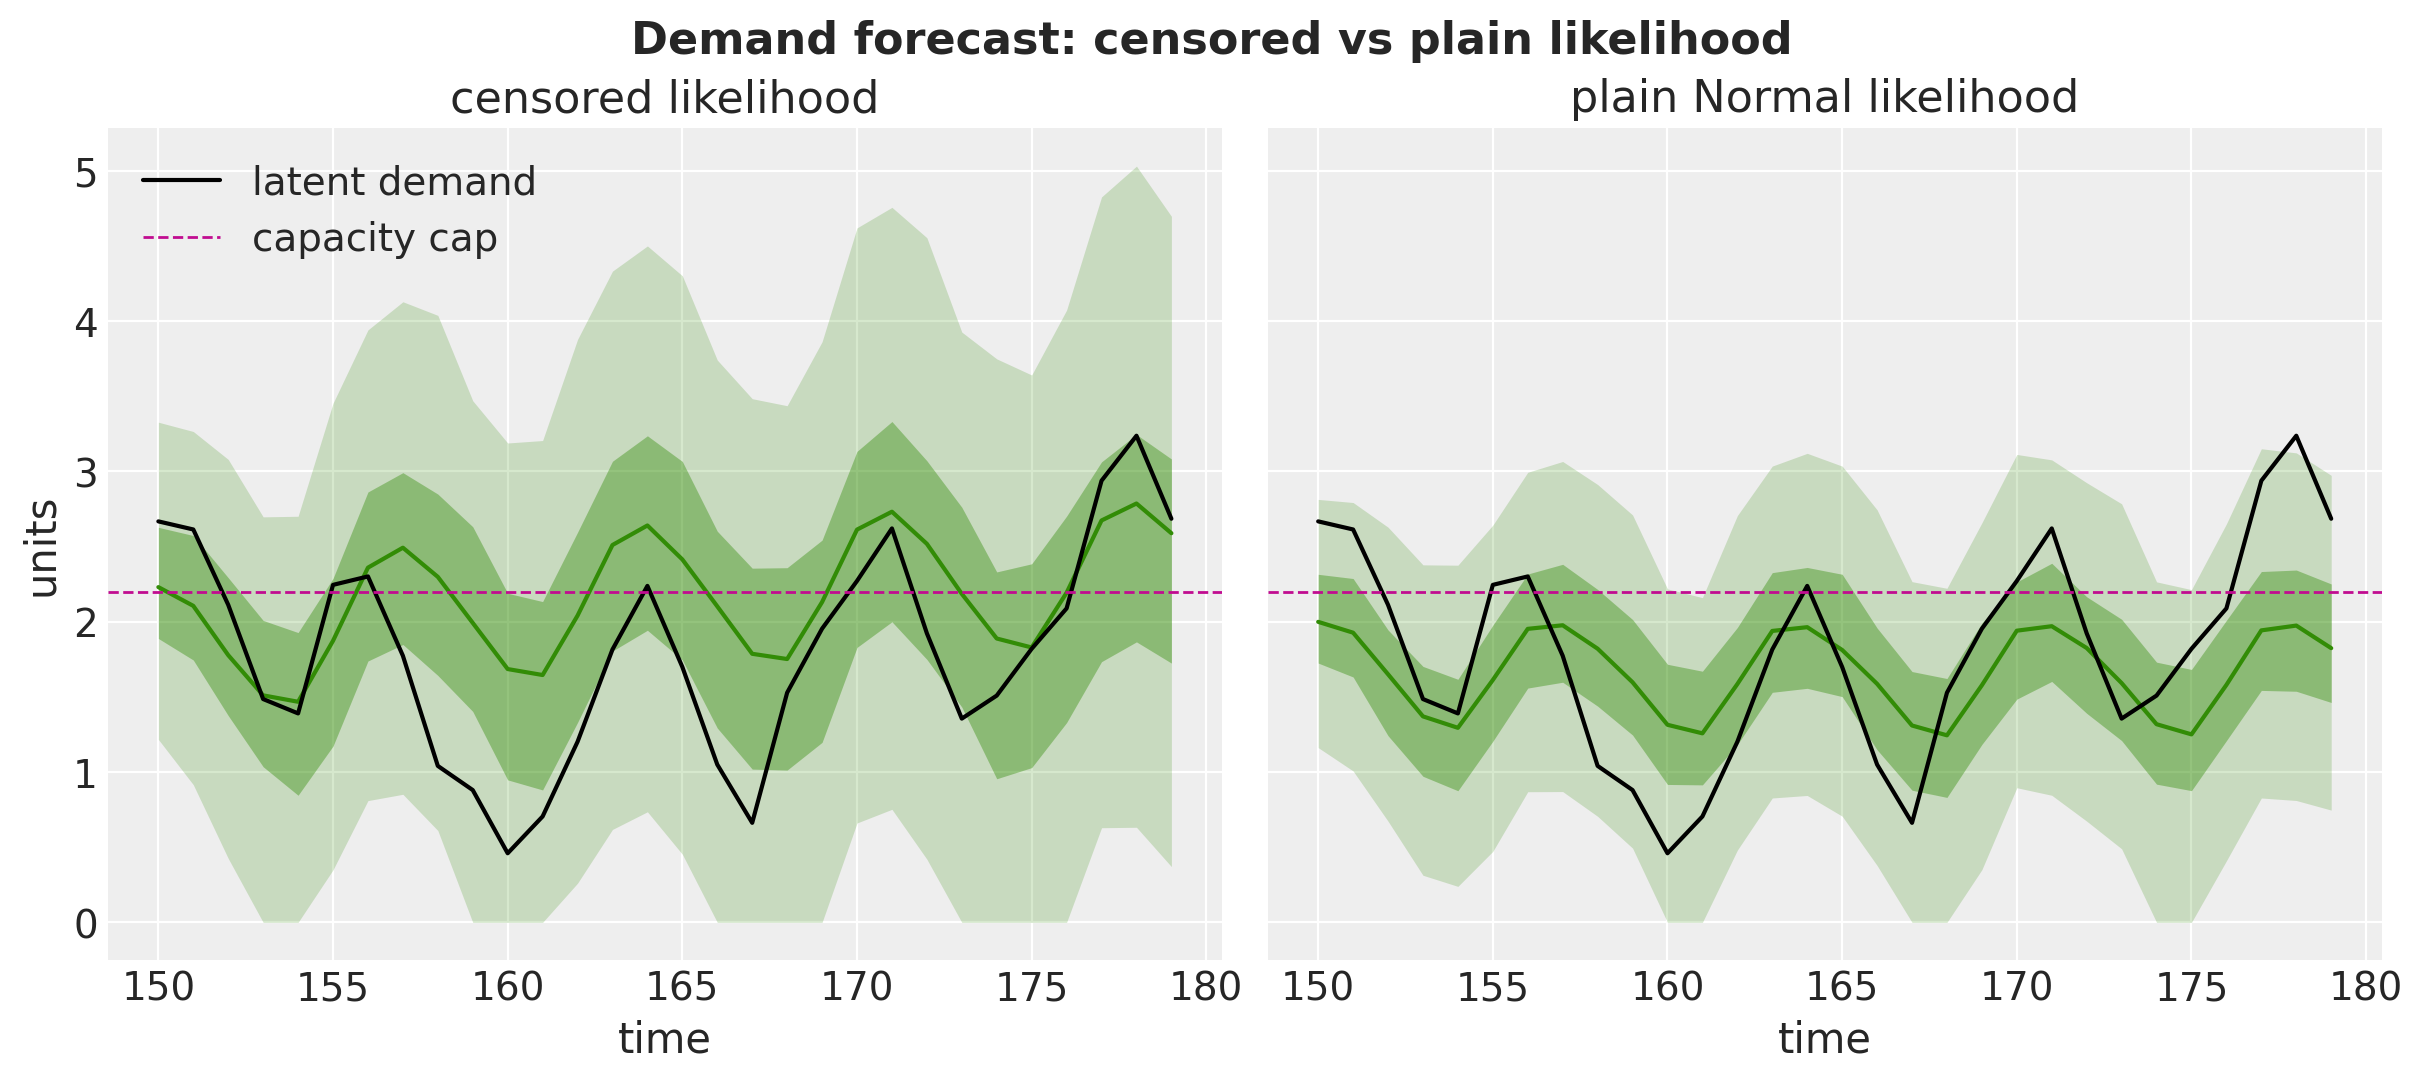

In [12]:
forecast_naive_pp = stacked_draws(tree_naive["predictions"], "obs")

series_names = ["censored likelihood", "plain Normal likelihood"]
both_draws = np.concatenate([forecast_pp, forecast_naive_pp], axis=-1)
idata_both = predictions_to_datatree(both_draws, t_test.astype(float), series_names)
pc = az.plot_lm(
    idata_both,
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=hdi_probs,
    smooth=False,
    point_estimate="mean",
    visuals={
        "ci_band": {"color": "C2"},
        "observed_scatter": False,
        "pe_line": {"color": "C2", "alpha": 1.0, "width": 1.5},
    },
    aes={"alpha": ["prob"]},
    alpha=hdi_alphas,
    figure_kwargs={"figsize": (12, 5), "sharex": True, "sharey": True},
)
axes = pc.viz["plot"]["t"]
for label in series_names:
    ax = axes.sel(series=label).item()
    ax.plot(t_test, np.asarray(demand[n_train:]), color="black", lw=1.5, label="latent demand")
    ax.axhline(params.max_capacity, color="C3", ls="--", lw=1, label="capacity cap")
    ax.set(title=label, xlabel="time", ylabel="")
axes.sel(series=series_names[0]).item().set(ylabel="units")
axes.sel(series=series_names[0]).item().legend(loc="upper left")
fig = pc.viz["figure"].item()
fig.suptitle(
    "Demand forecast: censored vs plain likelihood",
    fontsize=16,
    fontweight="bold",
    y=1.05,
);

## Evaluation

We score both models on the held-out $30$ days with
[`evaluate_forecast`](https://juanitorduz.github.io/numpyro_forecast/reference/evaluate.evaluate_forecast.html),
against two different notions of truth: the **latent demand** (the
business quantity, known here because we simulated it) and the
**observed sales** (the only truth available in production data, itself
gated and capped over the test window). Alongside the point metrics and
the CRPS we track the empirical coverage of the central $50\%$ and
$94\%$ intervals.

In [13]:
metrics = {
    "mae": eval_mae,
    "rmse": eval_rmse,
    "crps": eval_crps,
    "coverage_50": partial(eval_coverage, alpha=0.5),
    "coverage_94": partial(eval_coverage, alpha=0.94),
}

rows = {
    ("censored likelihood", "latent demand"): evaluate_forecast(
        forecast_pp, demand_test, metrics=metrics
    ),
    ("plain Normal likelihood", "latent demand"): evaluate_forecast(
        forecast_naive_pp, demand_test, metrics=metrics
    ),
    ("censored likelihood", "observed sales"): evaluate_forecast(
        forecast_pp, sales_obs_test, metrics=metrics
    ),
    ("plain Normal likelihood", "observed sales"): evaluate_forecast(
        forecast_naive_pp, sales_obs_test, metrics=metrics
    ),
}
results_df = pd.DataFrame(rows).T.round(3)
results_df.index.names = ["model", "truth"]
results_df

Two readings, one per truth:

- **Against latent demand**, the aggregate point metrics are nearly a
  wash: the two MAEs differ by three thousandths, and the naive model is
  ahead on RMSE and CRPS. This is expected. Both models target the
  *sales* scale, which sits below demand by the friction $\delta = 0.25$
  in expectation, so a modest downward offset against this truth is
  structural and shared. On the two thirds of test days where demand
  sits below the cap the two likelihoods largely agree, and there the
  naive model’s tighter, lower predictive scores well, offsetting its
  losses at the peaks. Calibration is where they separate: the censored
  model’s central intervals cover at or above their nominal levels at
  both widths, while the naive model’s $50\%$ interval falls short,
  because treating capped days as exact observations drags its mean down
  *and* shrinks its fitted noise scale (compare the $\sigma$ posteriors
  in the two summary tables).
- **Against observed sales**, the naive model wins the three point
  metrics (MAE, RMSE, CRPS), and that is not a defect but the fresh
  retail example’s lesson restated: the test window’s observed sales are
  themselves gated and capped, so a *correct* demand forecast is
  penalized for sitting above the caps and the stockout zeros. Scoring
  against recorded sales systematically favors models that repeat the
  corruption, though only on point accuracy: both models’ intervals sit
  far below nominal against this truth (the censored model covers
  $0.267$ at $50\%$ and $0.600$ at $94\%$, the naive model $0.300$ and
  $0.467$), and neither is clearly the better calibrated one. In
  production, where latent demand is unavailable, this is an argument
  for evaluating on periods or stores with clean availability.

Neither aggregate row answers the operational question, “how much should
we stock for the strong days?”, so we re-score on exactly the days that
drive that decision: the test days whose latent demand exceeds the cap,
the days a planner would under-stock by trusting the naive model.

In [14]:
peak_days = np.asarray(demand_test[:, 0] > params.max_capacity)
print(f"test days with latent demand above the cap: {int(peak_days.sum())} of {forecast_horizon}")

peak_rows = {
    "censored likelihood": evaluate_forecast(
        forecast_pp[:, peak_days, :], demand_test[peak_days], metrics=metrics
    ),
    "plain Normal likelihood": evaluate_forecast(
        forecast_naive_pp[:, peak_days, :], demand_test[peak_days], metrics=metrics
    ),
}
peak_df = pd.DataFrame(peak_rows).T.round(3)
peak_df.index.name = "model"
peak_df

test days with latent demand above the cap: 10 of 30

On the peak days the ambiguity disappears: the censored model roughly
halves the point errors and its central $50\%$ interval covers most of
the peak-day demand, while the naive model’s forecast mean tops out
below the cap it mistook for data (visible in the side-by-side plot
above), so its errors there are structural, not noise. The censored
model’s advantage is exactly where the money is: the days when there was
more demand than shelf.

## Three ways to model censoring

The fresh retail stockout example closes its next-steps list with:

> Replace the mean-level factor with a censored likelihood: treat sales
> as latent demand right-censored by the available stock, which uses the
> same availability feature but models the mechanism instead of its
> average effect.

This notebook is that item made concrete, on a synthetic process where
the recovered demand can be checked against ground truth. The three
examples form a progression of mechanisms for the same business problem:

| Example | Censoring pattern | Mechanism | Demand forecast |
|------------------|------------------|------------------|------------------|
| [Availability TSB](https://juanitorduz.github.io/numpyro_forecast/examples/availability_tsb.html) | Binary: off-shelf days record zero | Freeze the probability-recursion updates where the product is off the shelf | Feed a full-availability scenario input |
| [Fresh retail stockouts](https://juanitorduz.github.io/numpyro_forecast/examples/fresh_retail_stockout.html) | Fractional: noisy within-day availability | Multiplicative availability factor on the mean, with a learned floor | Pin availability to one over the horizon |
| This notebook | Hard capacity cap plus stockout mask | Censored likelihood: density below the cap, survival mass at it | The generative recursion, unconstrained by the cap |

The choice between them is driven by what the data records and how the
censoring operates:

- **Gating the recursion** (TSB) is the right tool when availability is
  binary and the model is a recursive smoother: off-shelf periods simply
  carry no information, so the estimate should freeze rather than decay.
- **A multiplicative factor** shines when availability is *fractional*
  and *noisy* (a reconstructed share of the day on the shelf): it models
  the average effect of partial availability on the mean, and its
  learned floor absorbs label noise such as recorded sales on supposedly
  out-of-stock days.
- **A censored likelihood** is the sharpest instrument when the
  censoring point is *known* per observation (a shelf capacity, an
  inventory level, a purchase limit): it models the mechanism itself
  rather than its average effect, at the price of trusting the recorded
  censoring indicator. All three share the same practical payoff: the
  corruption mechanism enters the model explicitly rather than as noise,
  so forecasting demand amounts to running the model with the mechanism
  switched off, whether through scenario covariate rows (TSB, fresh
  retail) or through a forecast recursion that never applies the cap
  (this notebook).

In practice the mechanisms compose: a retailer with hourly stockout
labels *and* known shelf capacities could use the fresh retail example’s
availability feature for partial days and this notebook’s survival terms
for capped ones.

## Next steps

- Replace the capped-day plug-in $\max(y_t, \hat{y}_t)$ in the lag
  filter with the censored conditional mean
  $\hat{y}_t + \sigma \, \varphi(z_t) / \left(1 - \Phi(z_t)\right)$ with
  $z_t = (y_t - \hat{y}_t) / \sigma$, the exact expectation of the
  latent value given that it exceeds the cap.
- Let the capacity cap vary by day, read from inventory snapshots,
  instead of a single constant. `RightCensoredDistribution` censors at
  each *recorded* value, so only the data preparation changes, not the
  model.
- Swap the $\text{Normal}$ base for a strictly nonnegative observation
  model (for example a truncated $\text{Normal}$), removing the
  predictive mass on negative sales visible in the in-sample bands.
- Replace the fixed train-test split with rolling-origin evaluation via
  the package’s `backtest` helper, as in the [Croston
  example](https://juanitorduz.github.io/numpyro_forecast/examples/croston.html).

## References

- Orduz, J. [*Demand Forecasting with Censored
  Likelihood*](https://juanitorduz.github.io/demand/). The blog post
  this notebook ports.
- NumPyro documentation: [Censored
  distributions](https://num.pyro.ai/en/stable/distributions.html#censored-distributions)
  (`RightCensoredDistribution` and friends, available from NumPyro
  `0.20.0`).
- Tobin, J. (1958). [*Estimation of Relationships for Limited Dependent
  Variables*](https://doi.org/10.2307/1907382). Econometrica, 26(1),
  24-36. The classic censored-regression (Tobit) model.
- The [ARMA
  example](https://juanitorduz.github.io/numpyro_forecast/examples/arma.html)
  in this documentation, which introduces the `ssoe` building block for
  AR-on-observations models.
- The [availability TSB
  example](https://juanitorduz.github.io/numpyro_forecast/examples/availability_tsb.html)
  and the [fresh retail stockout
  example](https://juanitorduz.github.io/numpyro_forecast/examples/fresh_retail_stockout.html)
  in this documentation: the sibling availability mechanisms compared
  above.